In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import skops.io as sio
sys.path.append('..')
from src.load_data import (
    load_all_data,
    TARGET_LABELS
)

RANDOM_STATE = 42

In [2]:
data = load_all_data(base_path='../data', random_state=RANDOM_STATE)

full_train_df = data['full_train']
full_test_df = data['full_test']

# Cap 'joy' samples at 12000 to reduce class imbalance, not too far from sadness & anger counts
joy_df = full_train_df[full_train_df['label'] == 'joy'].sample(n=12000, random_state=RANDOM_STATE)
other_df = full_train_df[full_train_df['label'] != 'joy']
full_train_df = pd.concat([joy_df, other_df], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Training Size: {len(full_train_df)}")
print(f"Test Size:     {len(full_test_df)}")

Training Size: 41974
Test Size:     6067


In [3]:
word_vectorizer = TfidfVectorizer(
    stop_words=None,
    sublinear_tf=True,
    min_df=5,
    max_features=20000,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\b\w\w+\b|!|\?|<3|:\)|:\(' # exclamation indeed matters
)

char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=5,
    max_features=15000
)

pipeline = Pipeline([
    ('features', FeatureUnion([
        ('word', word_vectorizer),
        ('char', char_vectorizer)
    ])),
    ('logreg', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

In [4]:
param_grid = {
    'logreg__C': [0.1, 1.0, 10.0],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
)

In [ ]:
grid_search.fit(full_train_df['text'], full_train_df['label'])

print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# On test set
y_pred = grid_search.predict(full_test_df['text'])
y_true = full_test_df['label']

print(f"\nFinal Test Accuracy (Best Model): {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, labels=TARGET_LABELS, target_names=TARGET_LABELS))

Statistics and Confusion Matrix

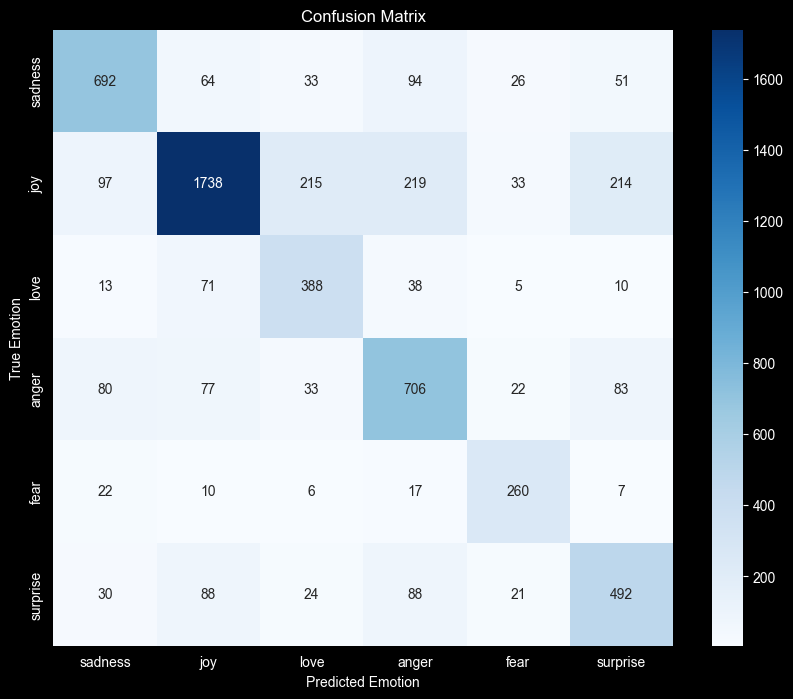

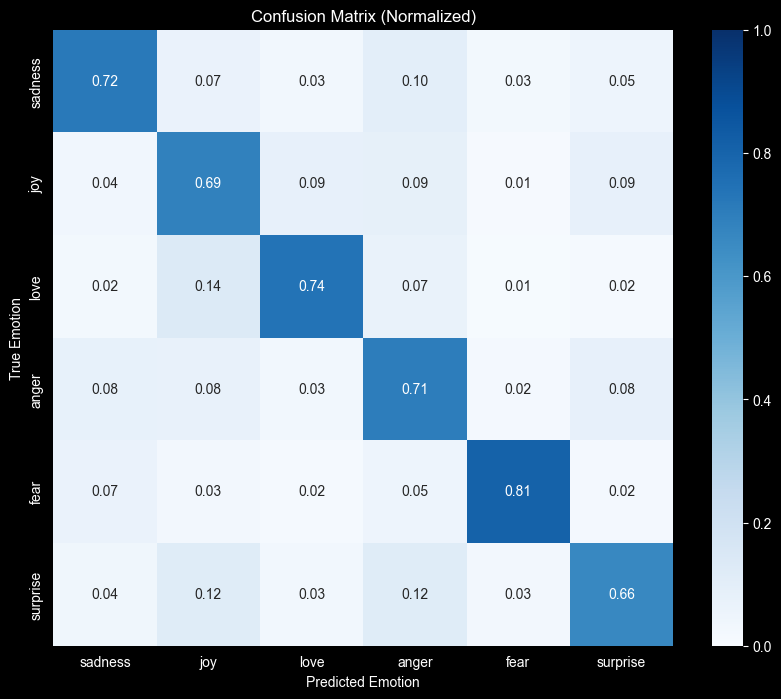

In [6]:
cm = confusion_matrix(y_true, y_pred, labels=TARGET_LABELS)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS)
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.title('Confusion Matrix')
plt.show()


# Normalized confusion matrix (row-normalized: per true class)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            vmin=0.0, vmax=1.0,
            xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS)
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.title('Confusion Matrix (Normalized)')
plt.show()

In [ ]:
best_model = grid_search.best_estimator_

classifier = best_model.named_steps['logreg']
feature_union = best_model.named_steps['features']

# Get feature names (Words + Chars)
word_names = feature_union.transformer_list[0][1].get_feature_names_out()
char_names = feature_union.transformer_list[1][1].get_feature_names_out()
all_feature_names = np.r_[word_names, char_names]

# Map Coefficients to Words
coef_df = pd.DataFrame(
    classifier.coef_,
    index=classifier.classes_,
    columns=all_feature_names
)

# Top 10 "Trigger Words" for each Emotion
print("Top Explainable Features per Emotion")
for emotion in TARGET_LABELS:
    # Sort by weight (highest positive weight = strongest trigger)
    top_triggers = coef_df.loc[emotion].sort_values(ascending=False).head(10)
    print(f"\nEmotion: {emotion.upper()}")
    for feature, weight in top_triggers.items():
        print(f"  {feature:20} (Weight: {weight:.2f})")

Save the model

In [8]:
model_path = "../models/6emotions_model.skops"
sio.dump(best_model, model_path)
print(f"Model saved to {model_path}")

Model saved to ../models/6emotions_model.skops
